# Sales Data Analysis
## Data Preprocessing & Exploratory Data Analysis (EDA)

This notebook performs a comprehensive analysis of sales data including:
- Data Preprocessing & Cleaning
- Exploratory Data Analysis (EDA)
- Visualizations & Insights

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

---
## 1. Data Loading & Initial Inspection

In [2]:
# Load the dataset
df = pd.read_csv('data/Sales Dataset.csv')

# Display basic info
print('='*60)
print('DATASET LOADED SUCCESSFULLY')
print('='*60)
print(f'Shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

DATASET LOADED SUCCESSFULLY
Shape: (1194, 12)

Number of rows: 1194
Number of columns: 12


In [3]:
# Display first 10 rows
df.head(10)

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
5,B-26776,4975,1330,14,Electronics,Printers,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
6,B-26942,1525,185,12,Office Supplies,Pens,Debit Card,2024-05-11,John Fields,Florida,Orlando,2024-05
7,B-26942,1525,185,12,Office Supplies,Pens,Debit Card,2021-10-09,Clayton Smith,Florida,Miami,2021-10
8,B-26640,883,117,10,Electronics,Laptops,EMI,2022-11-18,Richard Kelley,California,Los Angeles,2022-11
9,B-26640,8127,3551,16,Furniture,Tables,Credit Card,2022-11-18,Richard Kelley,California,Los Angeles,2022-11


In [4]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


In [5]:
# Column names
print('Columns in dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'{i}. {col}')

Columns in dataset:
1. Order ID
2. Amount
3. Profit
4. Quantity
5. Category
6. Sub-Category
7. PaymentMode
8. Order Date
9. CustomerName
10. State
11. City
12. Year-Month


---
## 2. Data Cleaning & Preprocessing

In [6]:
# Check for missing values
print('Missing Values per Column:')
print('='*40)
missing = df.isnull().sum()
for col, count in missing.items():
    pct = (count / len(df)) * 100
    print(f'{col}: {count} ({pct:.2f}%)')

Missing Values per Column:
Order ID: 0 (0.00%)
Amount: 0 (0.00%)
Profit: 0 (0.00%)
Quantity: 0 (0.00%)
Category: 0 (0.00%)
Sub-Category: 0 (0.00%)
PaymentMode: 0 (0.00%)
Order Date: 0 (0.00%)
CustomerName: 0 (0.00%)
State: 0 (0.00%)
City: 0 (0.00%)
Year-Month: 0 (0.00%)


In [7]:
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Total rows before removing duplicates: {len(df)}')

# Remove duplicates if any
df = df.drop_duplicates()
print(f'Total rows after removing duplicates: {len(df)}')

Duplicate rows: 0
Total rows before removing duplicates: 1194
Total rows after removing duplicates: 1194


In [8]:
# Convert data types
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year-Month'] = pd.to_datetime(df['Year-Month'])

# Verify data types
print('Updated Data Types:')
df.dtypes

Updated Data Types:


Order ID                object
Amount                   int64
Profit                   int64
Quantity                 int64
Category                object
Sub-Category            object
PaymentMode             object
Order Date      datetime64[ns]
CustomerName            object
State                   object
City                    object
Year-Month      datetime64[ns]
dtype: object

In [9]:
# Statistical summary of numerical columns
df.describe()

,Amount,Profit,Quantity,Order Date,Year-Month
count,1194.000000,1194.000000,1194.000000,1194,1194
mean,5178.089615,1348.992462,10.674204,2022-10-03 21:49:44.924623104,2022-09-18 21:28:02.412060160
min,508.000000,50.000000,1.000000,2020-03-22 00:00:00,2020-03-01 00:00:00
25%,2799.000000,410.000000,6.000000,2021-09-06 00:00:00,2021-09-01 00:00:00
50%,5152.000000,1014.000000,11.000000,2022-10-07 00:00:00,2022-10-01 00:00:00
75%,7626.000000,2035.000000,16.000000,2023-12-12 00:00:00,2023-12-01 00:00:00
max,9992.000000,4930.000000,20.000000,2025-03-15 00:00:00,2025-03-01 00:00:00
std,2804.921955,1117.992573,5.777102,NaN,NaN


In [10]:
# Check for negative or zero values in key columns
print('Checking for unusual values:')
print(f'Negative Amount: {(df["Amount"] < 0).sum()}')
print(f'Zero Amount: {(df["Amount"] == 0).sum()}')
print(f'Negative Profit: {(df["Profit"] < 0).sum()}')
print(f'Zero Quantity: {(df["Quantity"] == 0).sum()}')
print(f'Negative Quantity: {(df["Quantity"] < 0).sum()}')

Checking for unusual values:
Negative Amount: 0
Zero Amount: 0
Negative Profit: 0
Zero Quantity: 0
Negative Quantity: 0


---
## 3. Feature Engineering

In [11]:
# Extract date components
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Month_Name'] = df['Order Date'].dt.strftime('%B')
df['Order_Day'] = df['Order Date'].dt.day
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Order_DayName'] = df['Order Date'].dt.strftime('%A')
df['Order_Quarter'] = df['Order Date'].dt.quarter

# Calculate profit margin
df['Profit_Margin'] = (df['Profit'] / df['Amount']) * 100

# Calculate average price per unit
df['Avg_Price_Per_Unit'] = df['Amount'] / df['Quantity']

print('New features created successfully!')
print(f'\nTotal columns now: {len(df.columns)}')

New features created successfully!

Total columns now: 21


In [12]:
# Display updated dataframe info
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,...,Year-Month,Order_Year,Order_Month,Order_Month_Name,Order_Day,Order_DayOfWeek,Order_DayName,Order_Quarter,Profit_Margin,Avg_Price_Per_Unit
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,...,2023-06-01,2023,6,June,27,1,Tuesday,2,13.109192,1945.200000
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,...,2024-12-01,2024,12,December,27,4,Friday,4,13.109192,1945.200000
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,...,2021-07-01,2021,7,July,25,6,Sunday,3,13.109192,1945.200000
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,...,2023-06-01,2023,6,June,27,1,Tuesday,2,26.733668,355.357143
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,...,2024-12-01,2024,12,December,27,4,Friday,4,26.733668,355.357143


---
## 4. Descriptive Statistics

In [13]:
# Comprehensive statistics
print('='*60)
print('DESCRIPTIVE STATISTICS')
print('='*60)

stats_df = pd.DataFrame({
    'Metric': ['Total Sales (Amount)', 'Total Profit', 'Total Quantity Sold',
               'Average Order Amount', 'Average Profit', 'Average Quantity',
               'Median Order Amount', 'Median Profit',
               'Max Order Amount', 'Max Profit',
               'Min Order Amount', 'Min Profit',
               'Average Profit Margin (%)'],
    'Value': [
        df['Amount'].sum(),
        df['Profit'].sum(),
        df['Quantity'].sum(),
        df['Amount'].mean(),
        df['Profit'].mean(),
        df['Quantity'].mean(),
        df['Amount'].median(),
        df['Profit'].median(),
        df['Amount'].max(),
        df['Profit'].max(),
        df['Amount'].min(),
        df['Profit'].min(),
        df['Profit_Margin'].mean()
    ]
})

for _, row in stats_df.iterrows():
    if 'Margin' in row['Metric']:
        print(f"{row['Metric']}: {row['Value']:.2f}")
    else:
        print(f"{row['Metric']}: {row['Value']:,.2f}")

DESCRIPTIVE STATISTICS
Total Sales (Amount): 6,182,639.00
Total Profit: 1,610,697.00
Total Quantity Sold: 12,745.00
Average Order Amount: 5,178.09
Average Profit: 1,348.99
Average Quantity: 10.67
Median Order Amount: 5,152.00
Median Profit: 1,014.00
Max Order Amount: 9,992.00
Max Profit: 4,930.00
Min Order Amount: 508.00
Min Profit: 50.00
Average Profit Margin (%): 26.06


---
## 5. Univariate Analysis

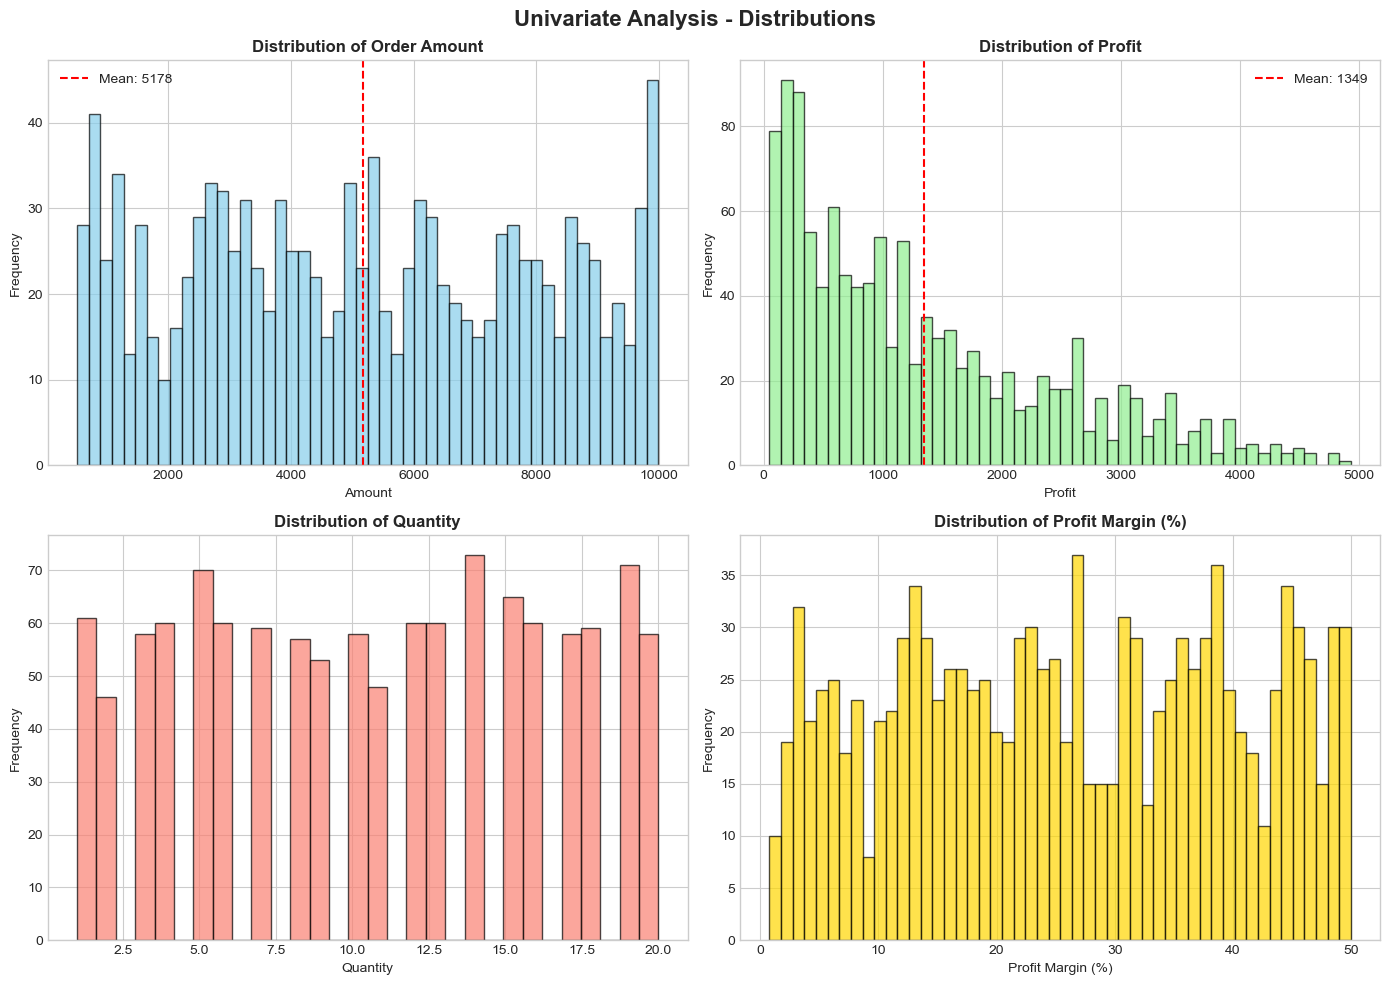

In [14]:
# Distribution plots for numerical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis - Distributions', fontsize=16, fontweight='bold')

# Amount distribution
axes[0, 0].hist(df['Amount'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Distribution of Order Amount', fontweight='bold')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['Amount'].mean(), color='red', linestyle='--', label=f"Mean: {df['Amount'].mean():.0f}")
axes[0, 0].legend()

# Profit distribution
axes[0, 1].hist(df['Profit'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Distribution of Profit', fontweight='bold')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['Profit'].mean(), color='red', linestyle='--', label=f"Mean: {df['Profit'].mean():.0f}")
axes[0, 1].legend()

# Quantity distribution
axes[1, 0].hist(df['Quantity'], bins=30, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 0].set_title('Distribution of Quantity', fontweight='bold')
axes[1, 0].set_xlabel('Quantity')
axes[1, 0].set_ylabel('Frequency')

# Profit Margin distribution
axes[1, 1].hist(df['Profit_Margin'], bins=50, edgecolor='black', alpha=0.7, color='gold')
axes[1, 1].set_title('Distribution of Profit Margin (%)', fontweight='bold')
axes[1, 1].set_xlabel('Profit Margin (%)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

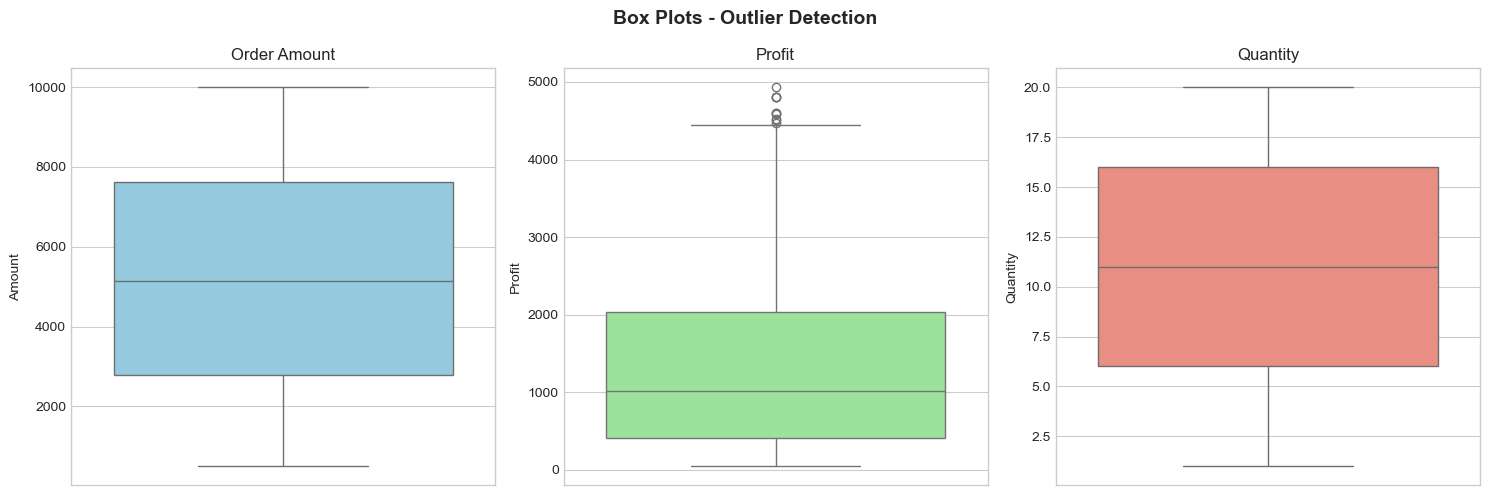

In [15]:
# Box plots to identify outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Box Plots - Outlier Detection', fontsize=14, fontweight='bold')

sns.boxplot(data=df, y='Amount', ax=axes[0], color='skyblue')
axes[0].set_title('Order Amount')

sns.boxplot(data=df, y='Profit', ax=axes[1], color='lightgreen')
axes[1].set_title('Profit')

sns.boxplot(data=df, y='Quantity', ax=axes[2], color='salmon')
axes[2].set_title('Quantity')

plt.tight_layout()
plt.show()

---
## 6. Bivariate Analysis & Correlations

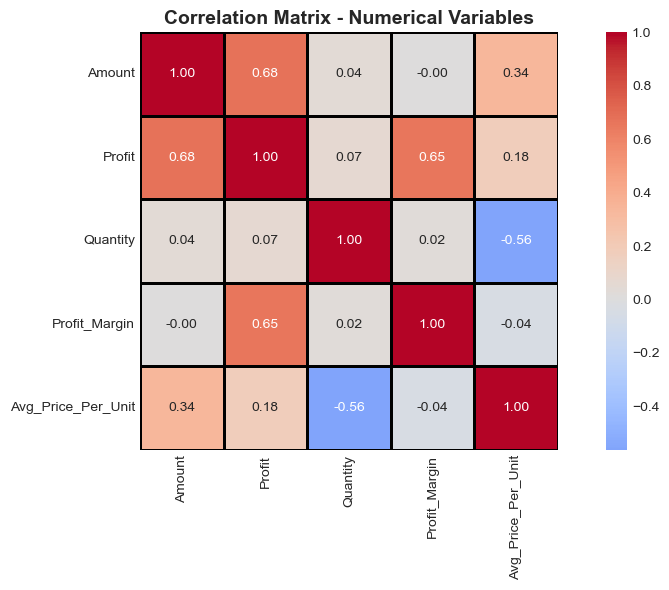

In [16]:
# Correlation matrix
correlation_cols = ['Amount', 'Profit', 'Quantity', 'Profit_Margin', 'Avg_Price_Per_Unit']
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, linecolor='black')
plt.title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

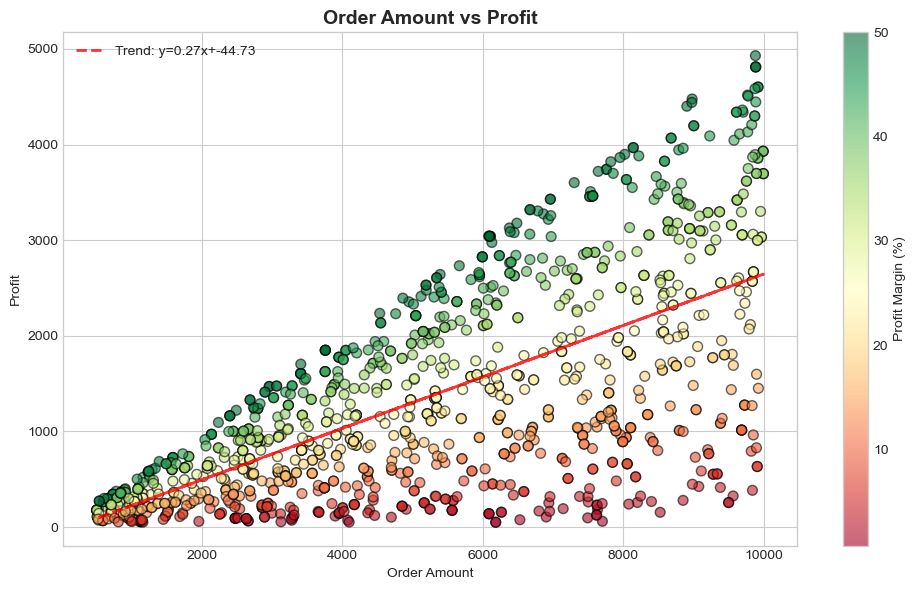

In [17]:
# Scatter plot: Amount vs Profit
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Amount'], df['Profit'], alpha=0.6, edgecolors='k', 
                     c=df['Profit_Margin'], cmap='RdYlGn', s=50)
plt.colorbar(scatter, label='Profit Margin (%)')
plt.title('Order Amount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Order Amount')
plt.ylabel('Profit')

# Add trend line
z = np.polyfit(df['Amount'], df['Profit'], 1)
p = np.poly1d(z)
plt.plot(df['Amount'], p(df['Amount']), 'r--', alpha=0.8, linewidth=2, 
         label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

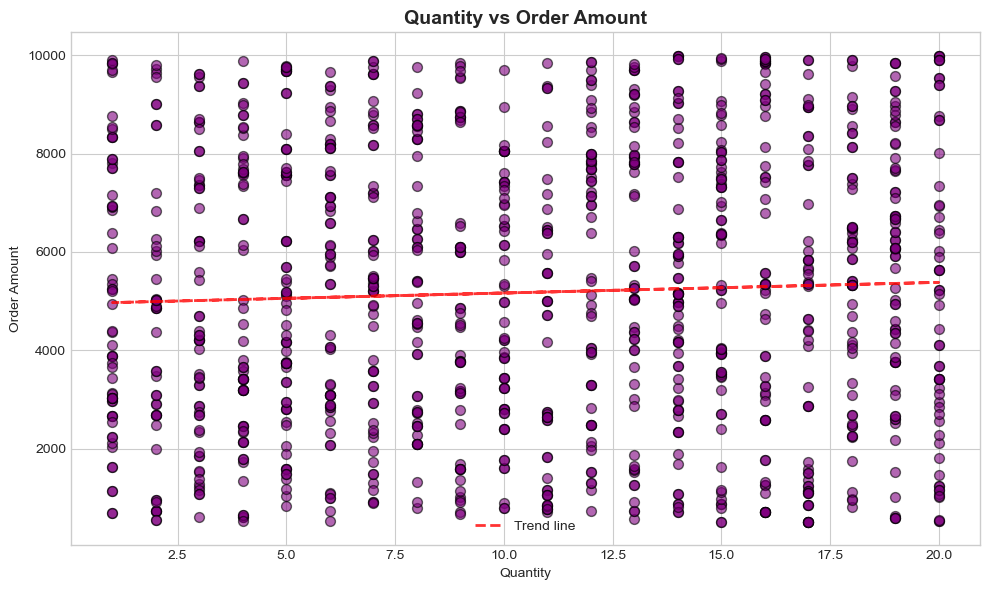

In [18]:
# Amount vs Quantity relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['Quantity'], df['Amount'], alpha=0.6, edgecolors='k', c='purple', s=50)
plt.title('Quantity vs Order Amount', fontsize=14, fontweight='bold')
plt.xlabel('Quantity')
plt.ylabel('Order Amount')

# Add trend line
z = np.polyfit(df['Quantity'], df['Amount'], 1)
p = np.poly1d(z)
plt.plot(df['Quantity'], p(df['Quantity']), 'r--', alpha=0.8, linewidth=2, 
         label=f'Trend line')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Categorical Analysis

In [19]:
# Analysis by Category
category_stats = df.groupby('Category').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Order ID': 'nunique'
}).round(2)

category_stats.columns = ['Total Amount', 'Avg Amount', 'Transaction Count',
                          'Total Profit', 'Avg Profit', 'Total Quantity', 'Unique Orders']
category_stats = category_stats.sort_values('Total Amount', ascending=False)
print('Sales by Category:')
print('='*80)
print(category_stats)

Sales by Category:
                 Total Amount  Avg Amount  Transaction Count  Total Profit  \
Category                                                                     
Office Supplies       2089510     5236.87                399        551575   
Electronics           2054456     5294.99                388        518580   
Furniture             2038673     5009.02                407        540542   

                 Avg Profit  Total Quantity  Unique Orders  
Category                                                    
Office Supplies     1382.39            4046            241  
Electronics         1336.55            4258            230  
Furniture           1328.11            4441            231  


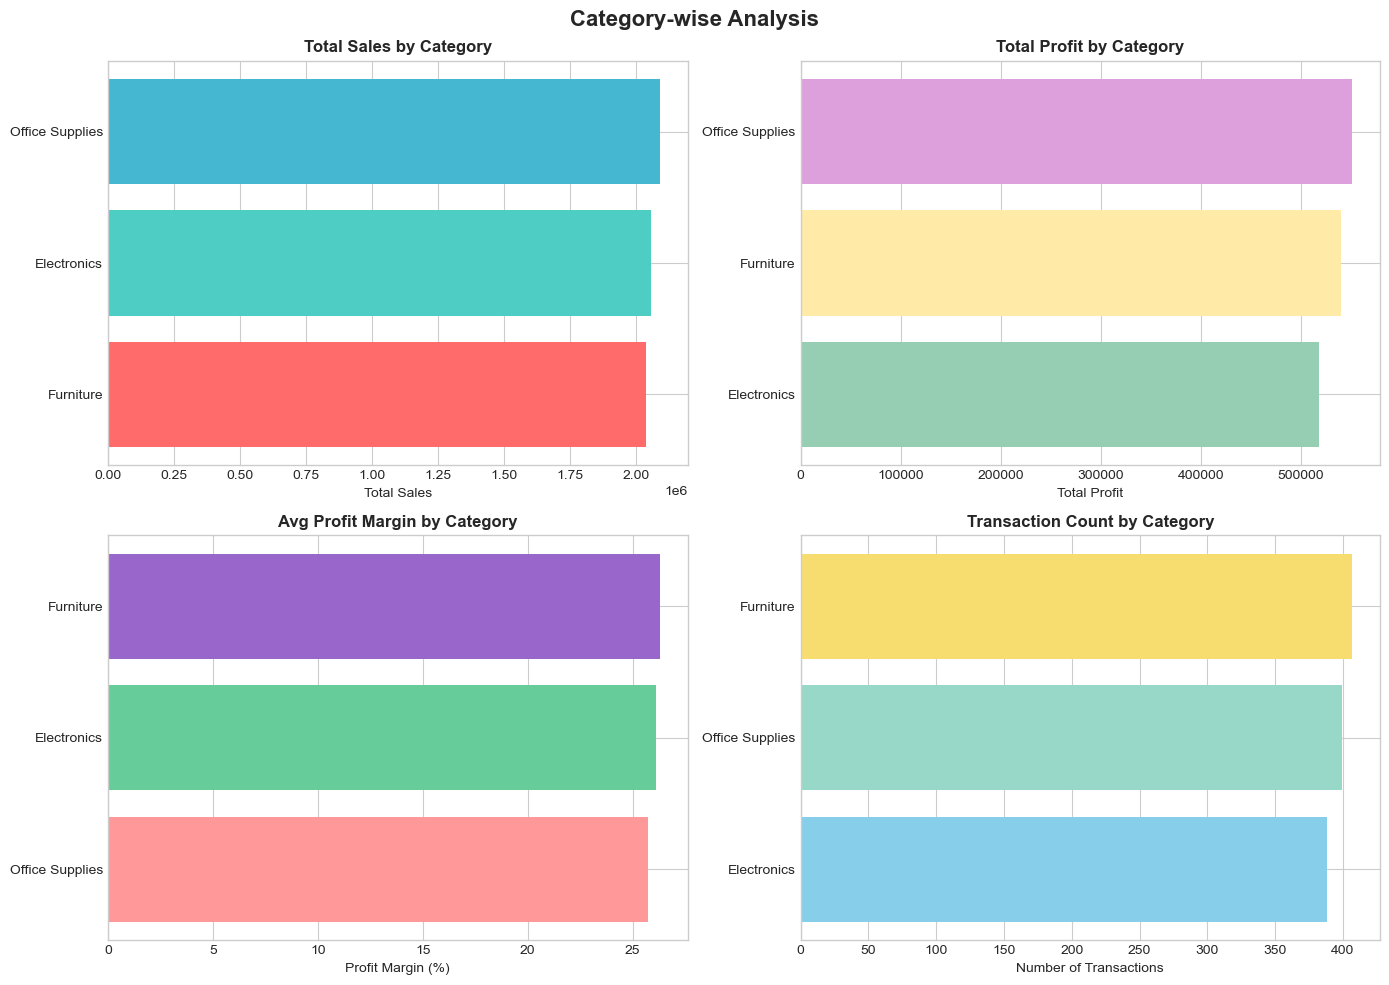

In [20]:
# Visualize Category performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Category-wise Analysis', fontsize=16, fontweight='bold')

# Total Sales by Category
cat_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=True)
axes[0, 0].barh(cat_sales.index, cat_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('Total Sales by Category', fontweight='bold')
axes[0, 0].set_xlabel('Total Sales')

# Total Profit by Category
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=True)
axes[0, 1].barh(cat_profit.index, cat_profit.values, color=['#96CEB4', '#FFEAA7', '#DDA0DD'])
axes[0, 1].set_title('Total Profit by Category', fontweight='bold')
axes[0, 1].set_xlabel('Total Profit')

# Average Profit Margin by Category
cat_margin = df.groupby('Category')['Profit_Margin'].mean().sort_values(ascending=True)
axes[1, 0].barh(cat_margin.index, cat_margin.values, color=['#FF9999', '#66CC99', '#9966CC'])
axes[1, 0].set_title('Avg Profit Margin by Category', fontweight='bold')
axes[1, 0].set_xlabel('Profit Margin (%)')

# Transaction Count by Category
cat_count = df.groupby('Category').size().sort_values(ascending=True)
axes[1, 1].barh(cat_count.index, cat_count.values, color=['#87CEEB', '#98D8C8', '#F7DC6F'])
axes[1, 1].set_title('Transaction Count by Category', fontweight='bold')
axes[1, 1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()

In [21]:
# Analysis by Sub-Category
subcategory_stats = df.groupby('Sub-Category').agg({
    'Amount': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum'
}).round(2)

subcategory_stats.columns = ['Total Amount', 'Avg Amount', 'Total Profit', 'Avg Profit', 'Total Quantity']
subcategory_stats = subcategory_stats.sort_values('Total Amount', ascending=False)
print('Sales by Sub-Category:')
print('='*80)
print(subcategory_stats)

Sales by Sub-Category:
                  Total Amount  Avg Amount  Total Profit  Avg Profit  \
Sub-Category                                                           
Markers                 627875     5707.95        174749     1588.63   
Tables                  625177     5124.40        156796     1285.21   
Sofas                   568367     4985.68        142854     1253.11   
Printers                566359     5961.67        146259     1539.57   
Electronic Games        565092     5433.58        148454     1427.44   
Pens                    552269     4844.46        129846     1139.00   
Paper                   524755     5045.72        149723     1439.64   
Phones                  503055     4980.74        113607     1124.82   
Chairs                  431964     5204.39        122892     1480.63   
Laptops                 419950     4772.16        110260     1252.95   
Bookcases               413165     4695.06        118000     1340.91   
Binders                 384611     5417.0

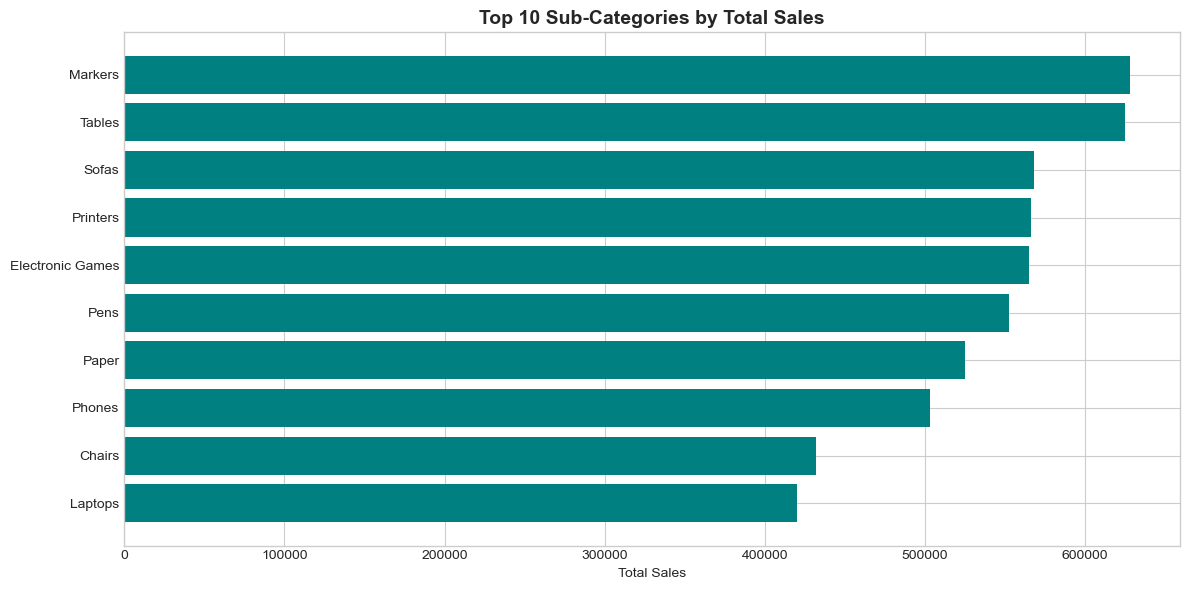

In [22]:
# Top 10 Sub-Categories by Sales
plt.figure(figsize=(12, 6))
top_10_subcat = df.groupby('Sub-Category')['Amount'].sum().sort_values(ascending=True).tail(10)
plt.barh(top_10_subcat.index, top_10_subcat.values, color='teal')
plt.title('Top 10 Sub-Categories by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

In [23]:
# Payment Mode Analysis
payment_stats = df.groupby('PaymentMode').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Profit': 'sum'
}).round(2)

payment_stats.columns = ['Total Amount', 'Avg Amount', 'Transaction Count', 'Total Profit']
payment_stats = payment_stats.sort_values('Total Amount', ascending=False)
print('Sales by Payment Mode:')
print('='*70)
print(payment_stats)

Sales by Payment Mode:
             Total Amount  Avg Amount  Transaction Count  Total Profit
PaymentMode                                                           
Debit Card        1395035     5365.52                260        375721
Credit Card       1281044     4965.29                258        349392
UPI               1250473     4962.19                252        333889
COD               1141790     5542.67                206        255744
EMI               1114297     5111.45                218        295951


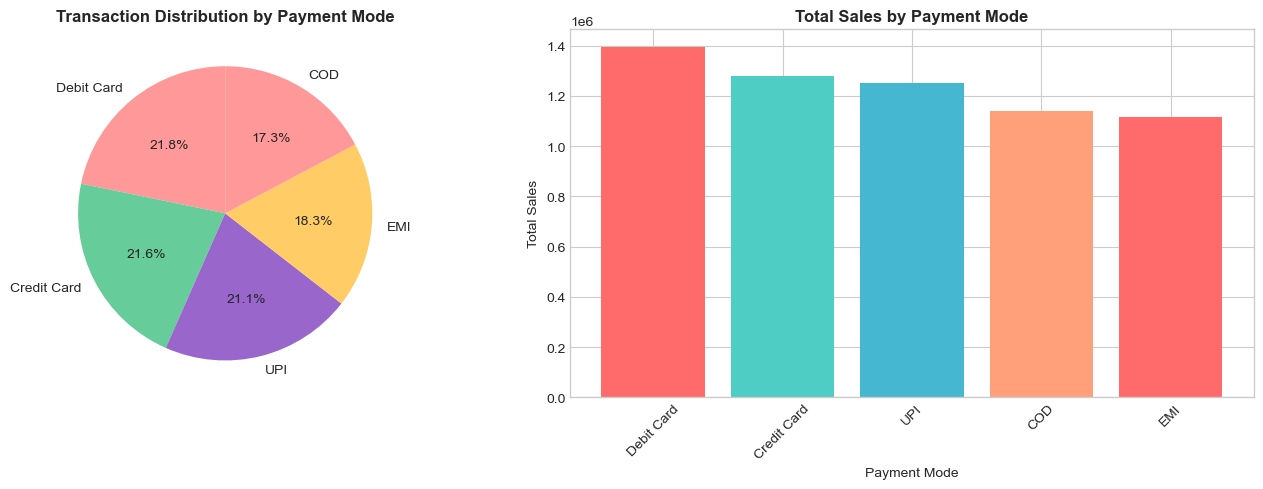

In [24]:
# Visualize Payment Mode distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart for payment mode distribution
payment_counts = df['PaymentMode'].value_counts()
axes[0].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=['#FF9999', '#66CC99', '#9966CC', '#FFCC66'])
axes[0].set_title('Transaction Distribution by Payment Mode', fontweight='bold')

# Bar chart for total sales by payment mode
payment_sales = df.groupby('PaymentMode')['Amount'].sum().sort_values(ascending=False)
axes[1].bar(payment_sales.index, payment_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1].set_title('Total Sales by Payment Mode', fontweight='bold')
axes[1].set_xlabel('Payment Mode')
axes[1].set_ylabel('Total Sales')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 8. Geographic Analysis

In [25]:
# Analysis by State
state_stats = df.groupby('State').agg({
    'Amount': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Order ID': 'nunique',
    'CustomerName': 'nunique'
}).round(2)

state_stats.columns = ['Total Sales', 'Avg Sales', 'Total Profit', 'Avg Profit', 
                       'Total Orders', 'Unique Customers']
state_stats = state_stats.sort_values('Total Sales', ascending=False)
print('Sales by State:')
print('='*90)
print(state_stats)

Sales by State:
            Total Sales  Avg Sales  Total Profit  Avg Profit  Total Orders  \
State                                                                        
New York        1130048    5000.21        308506     1365.07           139   
Florida         1091174    5455.87        308706     1543.53           122   
California      1086436    4983.65        278814     1278.96           131   
Texas           1011475    5351.72        257780     1363.92           121   
Illinois         978738    5407.39        240372     1328.02           118   
Ohio             884768    4915.38        216519     1202.88           116   

            Unique Customers  
State                         
New York                 151  
Florida                  134  
California               142  
Texas                    132  
Illinois                 125  
Ohio                     122  


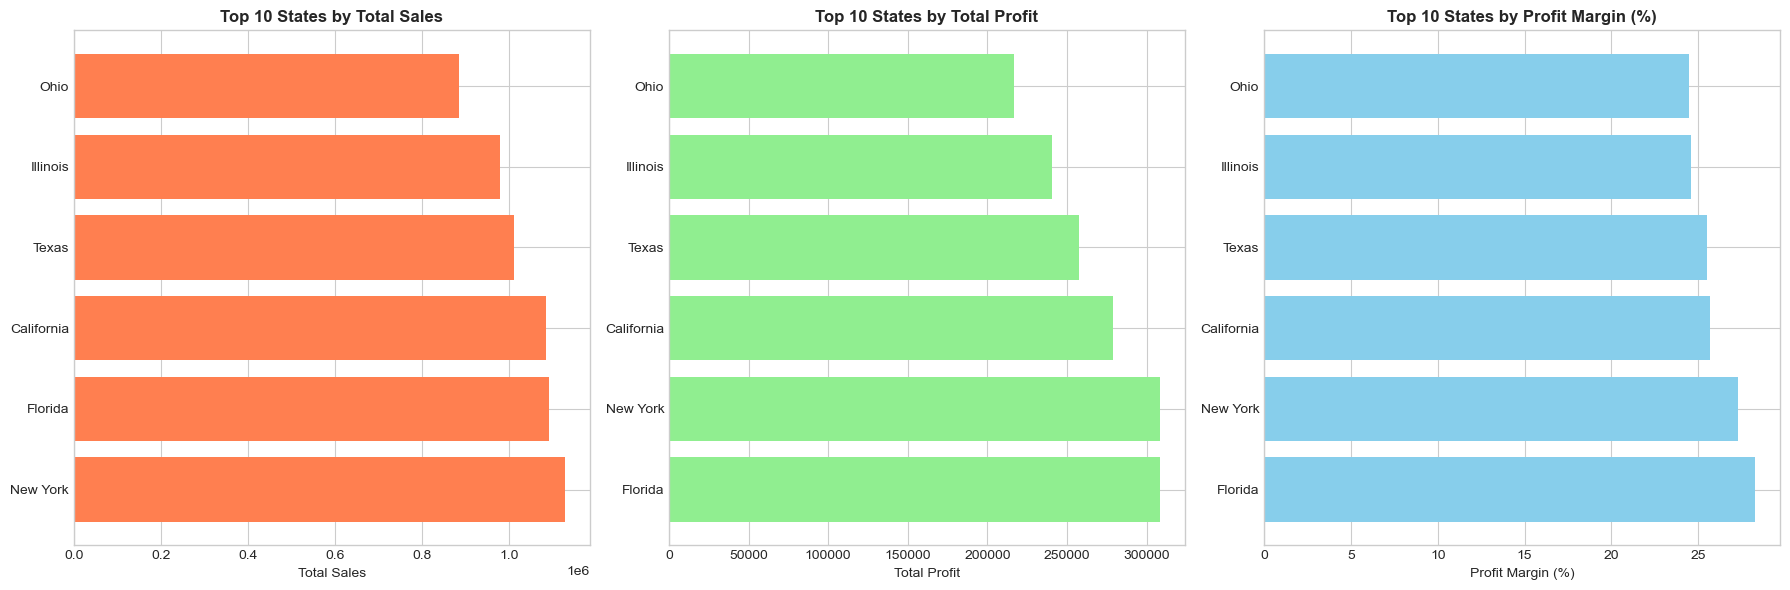

In [26]:
# Visualize State-wise performance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top 10 States by Sales
top_10_states = state_stats.head(10)
axes[0].barh(top_10_states.index, top_10_states['Total Sales'], color='coral')
axes[0].set_title('Top 10 States by Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Sales')

# Top 10 States by Profit
top_10_profit = state_stats.sort_values('Total Profit', ascending=False).head(10)
axes[1].barh(top_10_profit.index, top_10_profit['Total Profit'], color='lightgreen')
axes[1].set_title('Top 10 States by Total Profit', fontweight='bold')
axes[1].set_xlabel('Total Profit')

# Average Profit Margin by State
state_margin = (df.groupby('State').apply(lambda x: (x['Profit'].sum() / x['Amount'].sum()) * 100)
                .sort_values(ascending=False).head(10))
axes[2].barh(state_margin.index, state_margin.values, color='skyblue')
axes[2].set_title('Top 10 States by Profit Margin (%)', fontweight='bold')
axes[2].set_xlabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

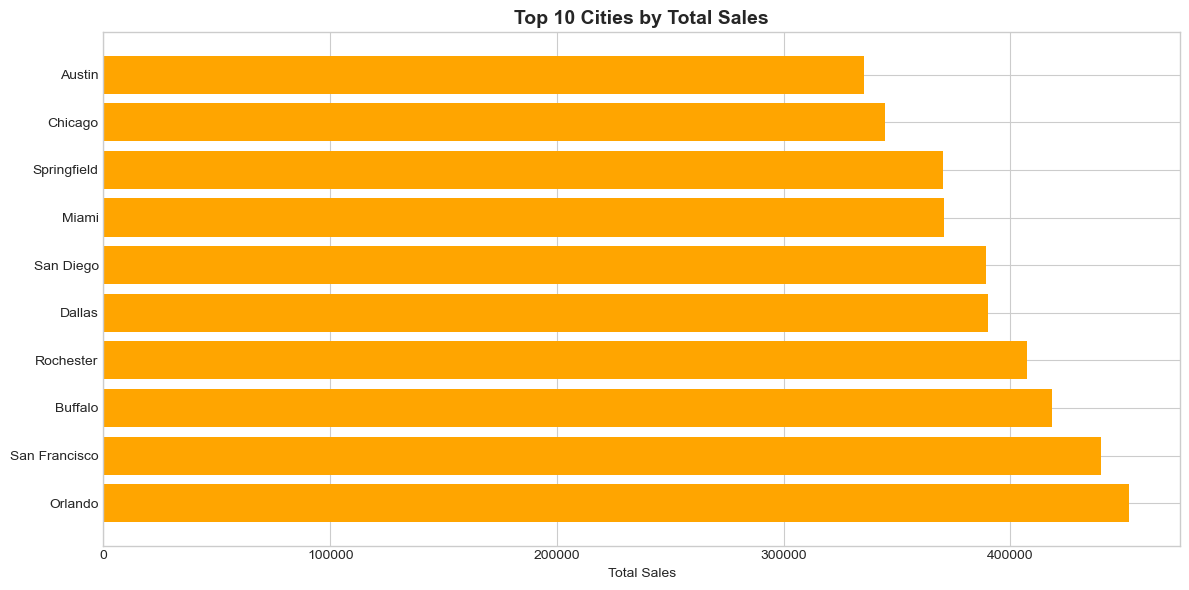

Top 10 Cities:
               Total Sales  Avg Sales  Total Profit  Total Orders
City                                                             
Orlando             452158    5872.18        128125            45
San Francisco       440000    5238.10        108106            51
Buffalo             418514    4650.16        111823            57
Rochester           407291    5503.93        109729            45
Dallas              390144    5418.67        102483            49
San Diego           389104    5330.19        101444            48
Miami               370881    5619.41        109739            45
Springfield         370131    5443.10         84205            46
Chicago             344675    5471.03         80061            39
Austin              335199    5156.91         82638            45


In [27]:
# Top 10 Cities by Sales
city_stats = df.groupby('City').agg({
    'Amount': ['sum', 'mean'],
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2)

city_stats.columns = ['Total Sales', 'Avg Sales', 'Total Profit', 'Total Orders']
city_stats = city_stats.sort_values('Total Sales', ascending=False)

plt.figure(figsize=(12, 6))
top_10_cities = city_stats.head(10)
plt.barh(top_10_cities.index, top_10_cities['Total Sales'], color='orange')
plt.title('Top 10 Cities by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

print('Top 10 Cities:')
print(top_10_cities)

---
## 9. Time Series Analysis

In [28]:
# Yearly trends
yearly_stats = df.groupby('Order_Year').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Order ID': 'nunique'
}).round(2)

yearly_stats.columns = ['Total Sales', 'Avg Sales', 'Total Orders', 
                        'Total Profit', 'Avg Profit', 'Total Quantity', 'Unique Orders']
print('Yearly Statistics:')
print('='*90)
print(yearly_stats)

Yearly Statistics:
            Total Sales  Avg Sales  Total Orders  Total Profit  Avg Profit  \
Order_Year                                                                   
2020             859401    5025.74           171        224103     1310.54   
2021            1181446    5444.45           217        283231     1305.21   
2022            1459775    5068.66           288        393113     1364.98   
2023            1229723    5255.23           234        321671     1374.66   
2024            1202478    5010.32           240        308336     1284.73   
2025             249816    5677.64            44         80243     1823.70   

            Total Quantity  Unique Orders  
Order_Year                                 
2020                  1695            111  
2021                  2358            138  
2022                  3234            171  
2023                  2497            143  
2024                  2523            148  
2025                   438             32  


In [29]:
# Yearly trends visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Yearly Trends', fontsize=16, fontweight='bold')

# Total Sales by Year
yearly_sales = df.groupby('Order_Year')['Amount'].sum()
axes[0, 0].bar(yearly_sales.index, yearly_sales.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Total Sales by Year', fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Total Sales')
for i, v in enumerate(yearly_sales.values):
    axes[0, 0].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

# Total Profit by Year
yearly_profit = df.groupby('Order_Year')['Profit'].sum()
axes[0, 1].bar(yearly_profit.index, yearly_profit.values, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Total Profit by Year', fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Total Profit')
for i, v in enumerate(yearly_profit.values):
    axes[0, 1].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

# Order Count by Year
yearly_orders = df.groupby('Order_Year').size()
axes[1, 0].bar(yearly_orders.index, yearly_orders.values, color='salmon', edgecolor='black')
axes[1, 0].set_title('Number of Orders by Year', fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Order Count')

# Average Profit Margin by Year
yearly_margin = df.groupby('Order_Year')['Profit_Margin'].mean()
axes[1, 1].plot(yearly_margin.index, yearly_margin.values, marker='o', linewidth=2, 
               markersize=10, color='purple')
axes[1, 1].set_title('Average Profit Margin by Year', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

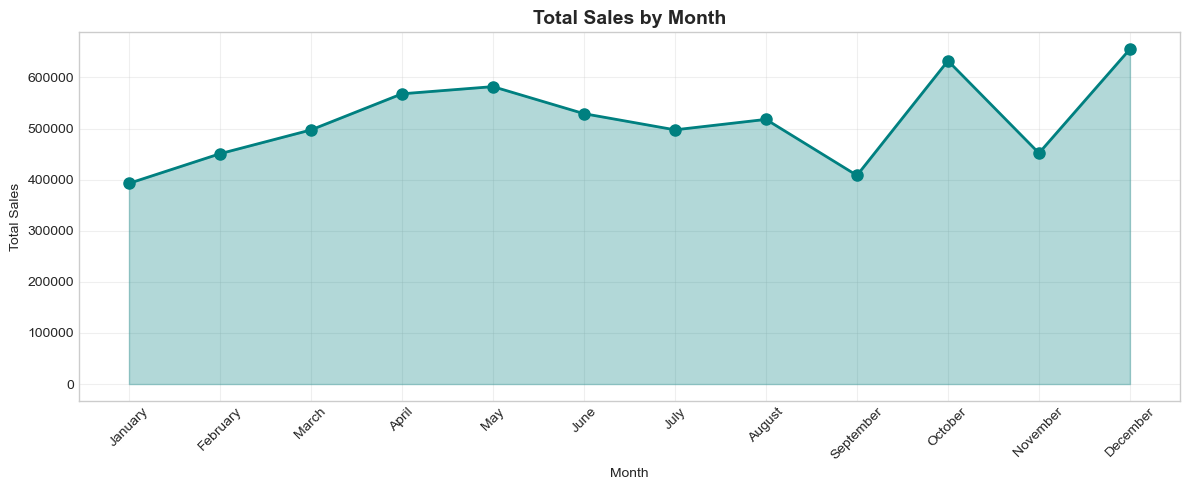

In [30]:
# Monthly trends
monthly_sales = df.groupby('Order_Month_Name')['Amount'].sum()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2, 
         markersize=8, color='teal')
plt.fill_between(range(len(monthly_sales.index)), monthly_sales.values, alpha=0.3, color='teal')
plt.title('Total Sales by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

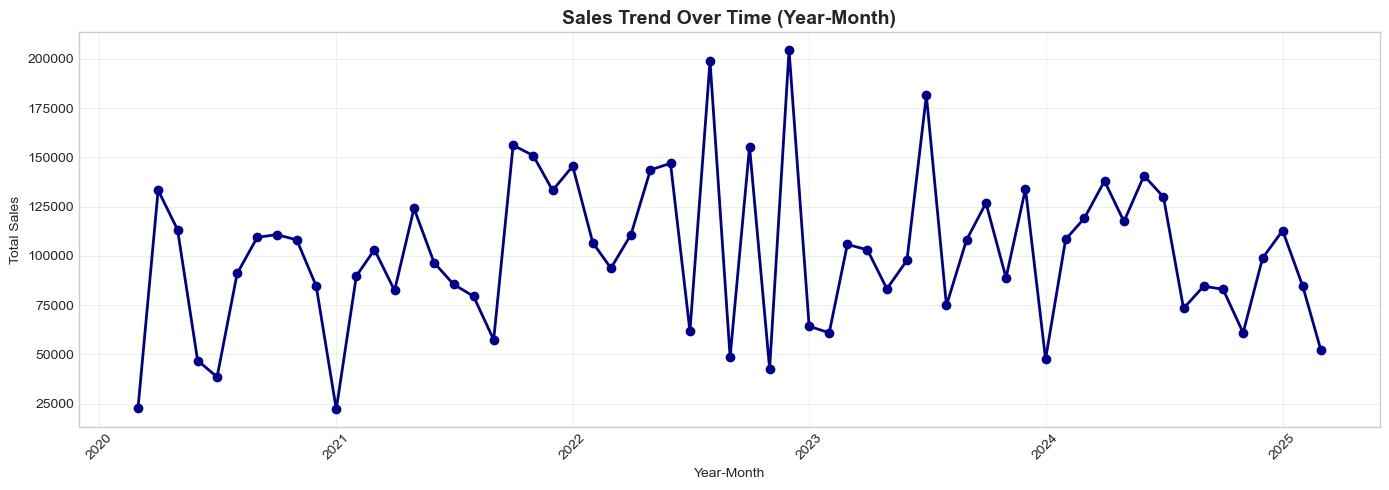

In [31]:
# Sales by Year-Month (Time trend)
ym_sales = df.groupby('Year-Month')['Amount'].sum().reset_index()
ym_sales['Year-Month'] = pd.to_datetime(ym_sales['Year-Month'])
ym_sales = ym_sales.sort_values('Year-Month')

plt.figure(figsize=(14, 5))
plt.plot(ym_sales['Year-Month'], ym_sales['Amount'], marker='o', 
         linewidth=2, markersize=6, color='darkblue')
plt.title('Sales Trend Over Time (Year-Month)', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

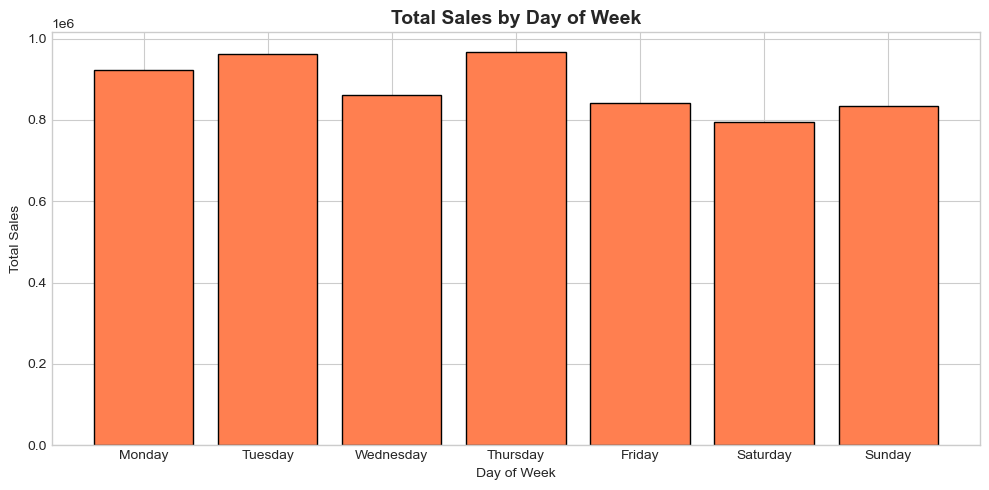

In [32]:
# Day of Week Analysis
dow_sales = df.groupby('Order_DayName')['Amount'].sum()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = dow_sales.reindex(dow_order)

plt.figure(figsize=(10, 5))
plt.bar(dow_sales.index, dow_sales.values, color='coral', edgecolor='black')
plt.title('Total Sales by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

---
## 10. Customer Analysis

In [33]:
# Top 10 Customers by Total Spending
customer_stats = df.groupby('CustomerName').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Profit': 'sum',
    'Quantity': 'sum',
    'State': 'first'
}).round(2)

customer_stats.columns = ['Total Spent', 'Avg Order Value', 'Order Count', 
                          'Total Profit', 'Total Quantity', 'State']
customer_stats = customer_stats.sort_values('Total Spent', ascending=False)

print('Top 10 Customers by Total Spending:')
print('='*90)
print(customer_stats.head(10))

Top 10 Customers by Total Spending:
                    Total Spent  Avg Order Value  Order Count  Total Profit  \
CustomerName                                                                  
Cory Evans                28557          7139.25            4          7790   
Emily Ellison             27352          9117.33            3          6848   
George Foster             27352          9117.33            3          6848   
Nicholas Anderson         27352          9117.33            3          6848   
Katherine Williams        25121          8373.67            3          5972   
Jacqueline Harris         24433          6108.25            4          6535   
Randy Johnson             24295          8098.33            3          5858   
Tammy Bell                23895          7965.00            3          6388   
Brian Green               23737          7912.33            3          4623   
Zachary Perez             23737          7912.33            3          4623   

               

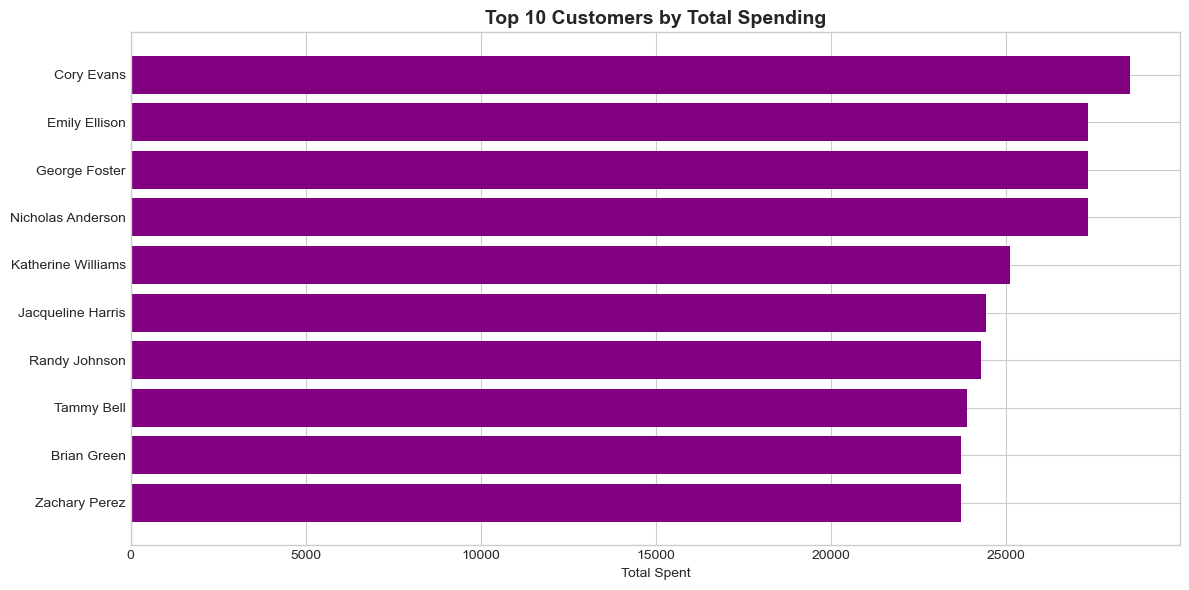

In [34]:
# Visualize top customers
plt.figure(figsize=(12, 6))
top_10_customers = customer_stats.head(10)
plt.barh(top_10_customers.index, top_10_customers['Total Spent'], color='purple')
plt.title('Top 10 Customers by Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Total Spent')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

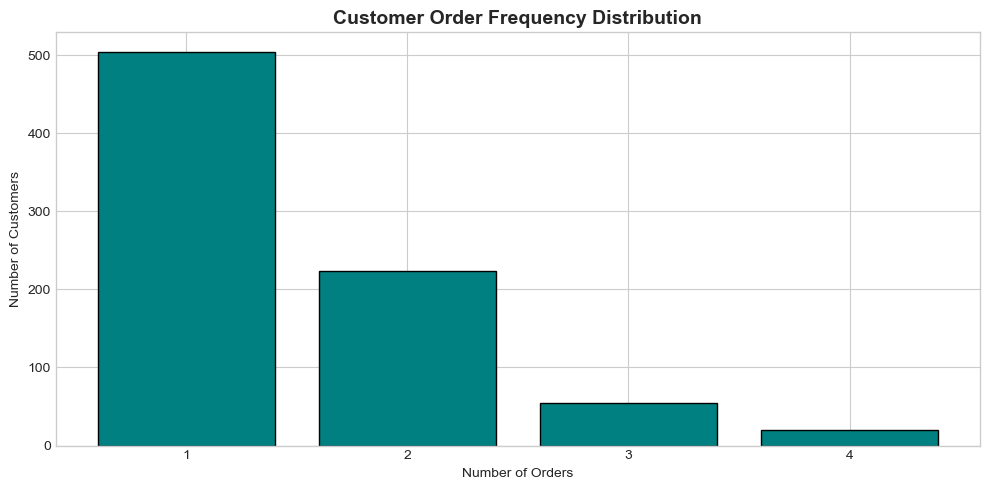

Order Frequency:
Order Count
1    504
2    224
3     54
4     20
Name: count, dtype: int64


In [35]:
# Customer order frequency
order_freq = customer_stats['Order Count'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(order_freq.index.astype(str), order_freq.values, color='teal', edgecolor='black')
plt.title('Customer Order Frequency Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print('Order Frequency:')
print(order_freq)

---
## 11. Profit Analysis

In [36]:
# Profit Margin Analysis
print('='*60)
print('PROFIT ANALYSIS')
print('='*60)
print(f'Average Profit Margin: {df["Profit_Margin"].mean():.2f}%')
print(f'Median Profit Margin: {df["Profit_Margin"].median():.2f}%')
print(f'Max Profit Margin: {df["Profit_Margin"].max():.2f}%')
print(f'Min Profit Margin: {df["Profit_Margin"].min():.2f}%')
print(f'Std Dev of Profit Margin: {df["Profit_Margin"].std():.2f}%')

PROFIT ANALYSIS
Average Profit Margin: 26.06%
Median Profit Margin: 25.57%
Max Profit Margin: 50.00%
Min Profit Margin: 0.78%
Std Dev of Profit Margin: 14.05%


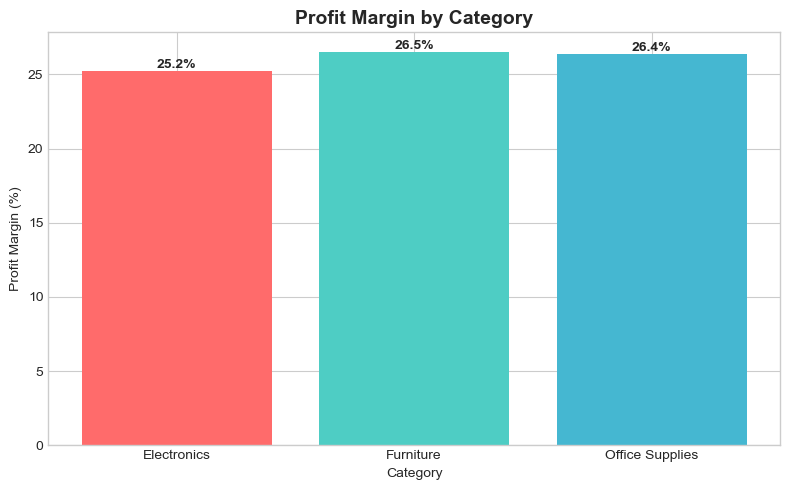

In [37]:
# Most and Least Profitable Categories
cat_profit_margin = df.groupby('Category').agg({
    'Profit': 'sum',
    'Amount': 'sum'
})
cat_profit_margin['Margin'] = (cat_profit_margin['Profit'] / cat_profit_margin['Amount']) * 100

plt.figure(figsize=(8, 5))
plt.bar(cat_profit_margin.index, cat_profit_margin['Margin'], 
        color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Profit Margin by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
for i, v in enumerate(cat_profit_margin['Margin']):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Negative Profit Analysis
negative_profit = df[df['Profit'] < 0]
print(f'\nTransactions with Negative Profit: {len(negative_profit)}')
print(f'Percentage: {(len(negative_profit) / len(df)) * 100:.2f}%')

if len(negative_profit) > 0:
    print('\nNegative Profit by Category:')
    neg_cat = negative_profit.groupby('Category').size().sort_values(ascending=False)
    print(neg_cat)


Transactions with Negative Profit: 0
Percentage: 0.00%


---
## 12. Key Insights & Summary

In [39]:
# Comprehensive Summary
print('='*70)
print('SALES DATA ANALYSIS - KEY INSIGHTS & SUMMARY')
print('='*70)

print('\n📊 GENERAL STATISTICS:')
print(f'  • Total Transactions: {len(df)}')
print(f'  • Total Revenue: ${df["Amount"].sum():,.2f}')
print(f'  • Total Profit: ${df["Profit"].sum():,.2f}')
print(f'  • Total Products Sold: {df["Quantity"].sum():,} units')
print(f'  • Average Order Value: ${df["Amount"].mean():,.2f}')
print(f'  • Average Profit per Transaction: ${df["Profit"].mean():,.2f}')

print('\n🏆 TOP PERFORMERS:')
top_category = df.groupby('Category')['Amount'].sum().idxmax()
top_subcategory = df.groupby('Sub-Category')['Amount'].sum().idxmax()
top_state = df.groupby('State')['Amount'].sum().idxmax()
top_customer = df.groupby('CustomerName')['Amount'].sum().idxmax()
top_payment = df.groupby('PaymentMode')['Amount'].sum().idxmax()

print(f'  • Best Category: {top_category}')
print(f'  • Best Sub-Category: {top_subcategory}')
print(f'  • Best State: {top_state}')
print(f'  • Best Customer: {top_customer}')
print(f'  • Preferred Payment: {top_payment}')

print('\n💰 PROFITABILITY:')
print(f'  • Overall Profit Margin: {(df["Profit"].sum() / df["Amount"].sum()) * 100:.2f}%')
print(f'  • Transactions with Losses: {len(negative_profit)} ({(len(negative_profit) / len(df)) * 100:.2f}%)')
print(f'  • Best Profit Margin Category: {cat_profit_margin["Margin"].idxmax()} ({cat_profit_margin["Margin"].max():.1f}%)')

print('\n📈 TRENDS:')
best_year = df.groupby('Order_Year')['Amount'].sum().idxmax()
print(f'  • Best Year: {best_year}')
print(f'  • Data Span: {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')

print('\n👥 CUSTOMERS:')
print(f'  • Total Unique Customers: {df["CustomerName"].nunique()}')
print(f'  • Avg Orders per Customer: {(len(df) / df["CustomerName"].nunique()):.2f}')

print('\n' + '='*70)

SALES DATA ANALYSIS - KEY INSIGHTS & SUMMARY

📊 GENERAL STATISTICS:
  • Total Transactions: 1194
  • Total Revenue: $6,182,639.00
  • Total Profit: $1,610,697.00
  • Total Products Sold: 12,745 units
  • Average Order Value: $5,178.09
  • Average Profit per Transaction: $1,348.99

🏆 TOP PERFORMERS:
  • Best Category: Office Supplies
  • Best Sub-Category: Markers
  • Best State: New York
  • Best Customer: Cory Evans
  • Preferred Payment: Debit Card

💰 PROFITABILITY:
  • Overall Profit Margin: 26.05%
  • Transactions with Losses: 0 (0.00%)
  • Best Profit Margin Category: Furniture (26.5%)

📈 TRENDS:
  • Best Year: 2022
  • Data Span: 2020-03-22 to 2025-03-15

👥 CUSTOMERS:
  • Total Unique Customers: 802
  • Avg Orders per Customer: 1.49



---
## 13. Advanced Insights - Cross Analysis

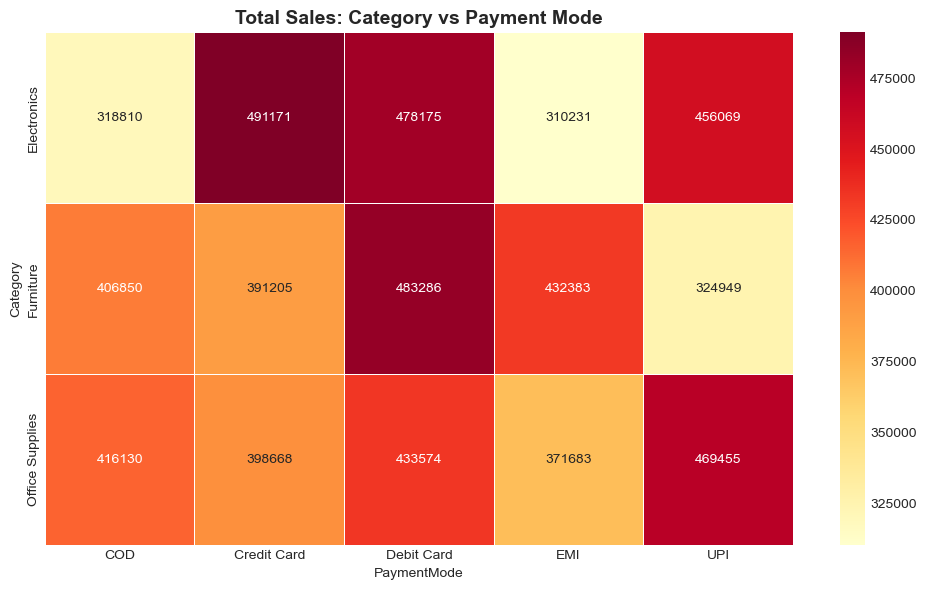

In [40]:
# Category vs Payment Mode heatmap
cat_payment = pd.crosstab(df['Category'], df['PaymentMode'], values=df['Amount'], aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(cat_payment, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Total Sales: Category vs Payment Mode', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

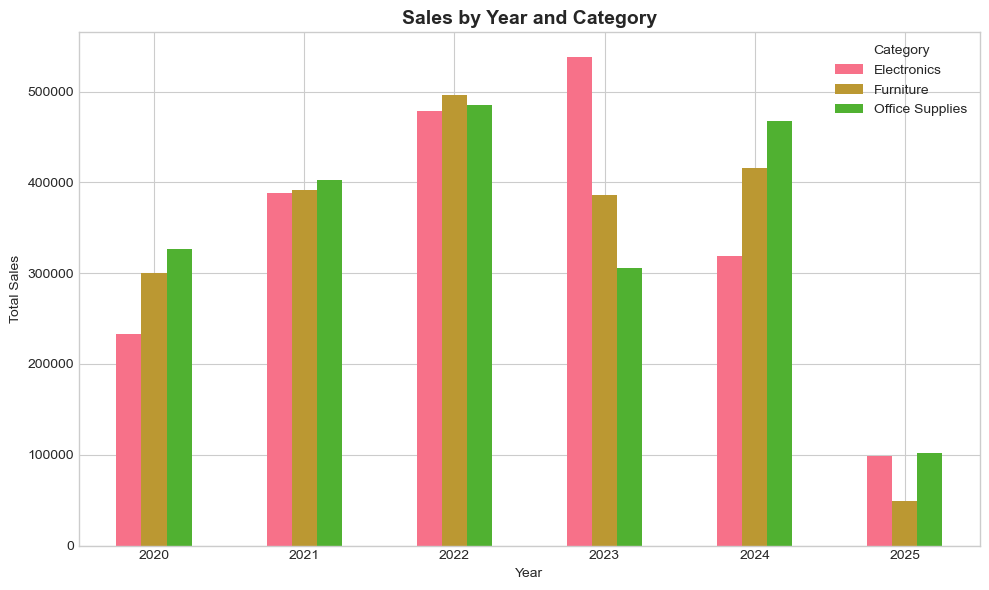

In [41]:
# Year vs Category analysis
year_cat = pd.crosstab(df['Order_Year'], df['Category'], values=df['Amount'], aggfunc='sum')

plt.figure(figsize=(10, 6))
year_cat.plot(kind='bar', ax=plt.gca())
plt.title('Sales by Year and Category', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

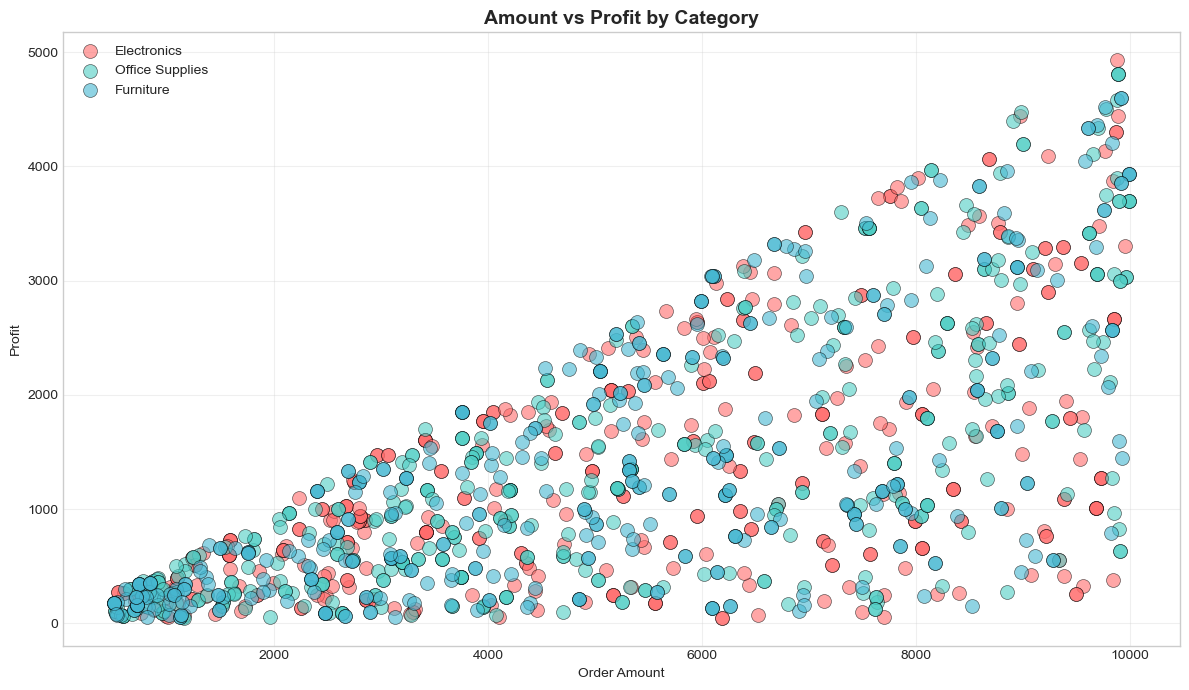

In [42]:
# Profit vs Amount by Category (scatter with size)
plt.figure(figsize=(12, 7))
categories = df['Category'].unique()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for cat, color in zip(categories, colors):
    subset = df[df['Category'] == cat]
    plt.scatter(subset['Amount'], subset['Profit'], 
               alpha=0.6, s=100, c=color, label=cat, edgecolors='black', linewidth=0.5)

plt.title('Amount vs Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Order Amount')
plt.ylabel('Profit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()